# Notebook 04 — Construction du portefeuille et backtest

**Objectif** : Comparer 4 stratégies sur la période de test.

| Stratégie | Description |
|-----------|-------------|
| Equal Weight | 1/N pour chaque actif — baseline naïve |
| Markowitz classique | Optimisation moyenne-variance |
| GAT + Markowitz | Prédictions GAT comme μ dans Markowitz |
| GNN + RL | Agent RL entraîné avec embeddings GNN |

**Métriques** : Rendement annualisé, Volatilité, Sharpe Ratio, Max Drawdown

**Référence** : Zhang (2026) — Table 5, résultats sur S&P 500

In [2]:
import sys, os
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from src.portfolio import PortfolioBuilder, Backtester, compute_metrics
from src.portfolio import PortfolioEnv, PortfolioRLAgent, RLTrainer
from src.gnn_model  import GATModel, GNNTrainer

# Charger tout
returns    = pd.read_parquet('../data/returns.parquet')
dynamic_graphs = torch.load('../data/dynamic_graphs.pt', weights_only=False)
gcn_preds  = np.load('../data/gcn_predictions.npy')
gat_preds  = np.load('../data/gat_predictions.npy')

# Split temporel : 80% train, 20% test
split = int(len(returns) * 0.8)
returns_train = returns.iloc[:split]
returns_test  = returns.iloc[split:]
print(f"Test : {returns_test.index[0].date()} → {returns_test.index[-1].date()} ({len(returns_test)} jours)")

Test : 2022-10-18 → 2023-12-29 (302 jours)


## 1. Stratégie 1 — Equal Weight (baseline)

In [3]:
builder_train = PortfolioBuilder(returns_train)

w_ew = builder_train.equal_weight()
print(f"Equal Weight : {w_ew[:5]} ... (tous = {1/len(w_ew):.4f})")

Equal Weight : [0.03571429 0.03571429 0.03571429 0.03571429 0.03571429] ... (tous = 0.0357)


## 2. Stratégie 2 — Markowitz classique

Optimisation : `max w^T μ - (λ/2) w^T Σ w`

μ = rendements moyens historiques (période d'entraînement)

In [4]:
w_markowitz = builder_train.markowitz_weights(risk_aversion=1.0)

# Afficher les 5 actifs les plus pondérés
tickers = list(returns.columns)
mk_df = pd.Series(w_markowitz, index=tickers).sort_values(ascending=False)
print("Top 5 poids Markowitz :")
print(mk_df.head())

Top 5 poids Markowitz :
AAPL    1.000000e+00
MSFT    3.469447e-16
MRK     1.082034e-16
CSCO    2.602085e-17
CVX     1.561251e-17
dtype: float32


## 3. Stratégie 3 — GAT + Markowitz

On utilise les **prédictions du GAT** comme rendements attendus μ dans Markowitz.
La structure relationnelle capturée par le GAT remplace la moyenne historique.

In [5]:
builder_gat = PortfolioBuilder(returns_train, predictions=gat_preds)
w_gat_mk    = builder_gat.gnn_markowitz_weights(risk_aversion=1.0)

gat_df = pd.Series(w_gat_mk, index=tickers).sort_values(ascending=False)
print("Top 5 poids GAT + Markowitz :")
print(gat_df.head())

Top 5 poids GAT + Markowitz :
NKE     7.992746e-01
INTC    2.007254e-01
WMT     8.636610e-16
JPM     1.062866e-16
HD      1.002126e-16
dtype: float32


## 4. Stratégie 4 — GNN + RL (niveau excellent)

L'agent RL est entraîné à maximiser le Sharpe Ratio cumulé.
L'état de l'agent inclut les embeddings du GNN (information structurelle du marché).

⚠️ **Note** : Pour la démo rapide, on réduit les épisodes. En production : 500+ épisodes.

In [9]:
returns    = pd.read_parquet('../data/returns.parquet')
graph_data = torch.load('../data/static_graph.pt', weights_only=False)
gcn_preds  = np.load('../data/gcn_predictions.npy')
gat_preds  = np.load('../data/gat_predictions.npy')
n_assets = len(tickers)
gnn_embed_dim = graph_data.x.shape[1]

# L'état = features GNN (5 dim × n_actifs) + poids courants (n_actifs)
state_dim = gnn_embed_dim * n_assets + n_assets

# Créer les embeddings GNN répétés sur toute la période d'entraînement
# (version simplifiée — dans le niveau excellent, utiliser graphes dynamiques)
gnn_embed_static = graph_data.x.numpy()  # (n_actifs × n_features)
gnn_embeds_train = np.tile(gnn_embed_static, (len(returns_train), 1, 1))

env   = PortfolioEnv(returns_train, gnn_embeds_train, window=20, transaction_cost=0.001)
agent = PortfolioRLAgent(n_assets=n_assets, state_dim=state_dim, hidden=128)
rl_trainer = RLTrainer(agent, env, lr=3e-4, gamma=0.99)

# Entraînement RL (50 épisodes pour la démo, 200+ recommandé)
rl_trainer.train(n_episodes=50, verbose_every=10)

# Obtenir les poids finaux de l'agent
state_final = env.reset()
w_rl = rl_trainer.get_weights(state_final)
print(f"\nPoids RL — Top 5 :")
rl_df = pd.Series(w_rl, index=tickers).sort_values(ascending=False)
print(rl_df.head())

[RLTrainer] Entraînement 50 épisodes sur cpu
  Épisode   10/50 | Récompense moy. : 1480.8855
  Épisode   20/50 | Récompense moy. : 1482.4882
  Épisode   30/50 | Récompense moy. : 1483.4155
  Épisode   40/50 | Récompense moy. : 1483.7895
  Épisode   50/50 | Récompense moy. : 1480.2212

Poids RL — Top 5 :
INTC    0.039924
JNJ     0.039394
WMT     0.039297
AXP     0.038862
HD      0.038564
dtype: float32


## 5. Backtest sur la période de test

In [10]:
bt = Backtester(returns_test, rebalance_freq=20)

bt.add_strategy('Equal Weight',     w_ew)
bt.add_strategy('Markowitz',        w_markowitz)
bt.add_strategy('GAT + Markowitz',  w_gat_mk)
bt.add_strategy('GNN + RL',         w_rl)

# Tableau des métriques
metrics = bt.compute_all_metrics()
print("══ RÉSULTATS DU BACKTEST ══")
print(metrics.to_string())

══ RÉSULTATS DU BACKTEST ══
                 Rendement annualisé (%)  Volatilité annualisée (%)  Sharpe Ratio  Max Drawdown (%)  Sortino Ratio  Calmar Ratio
Equal Weight                       20.81                      13.09         1.590             -8.47          2.676         2.457
Markowitz                          25.77                      24.93         1.034            -20.66          1.619         1.247
GAT + Markowitz                    24.97                      28.66         0.871            -23.77          1.398         1.050
GNN + RL                           20.84                      13.19         1.580             -8.48          2.665         2.459


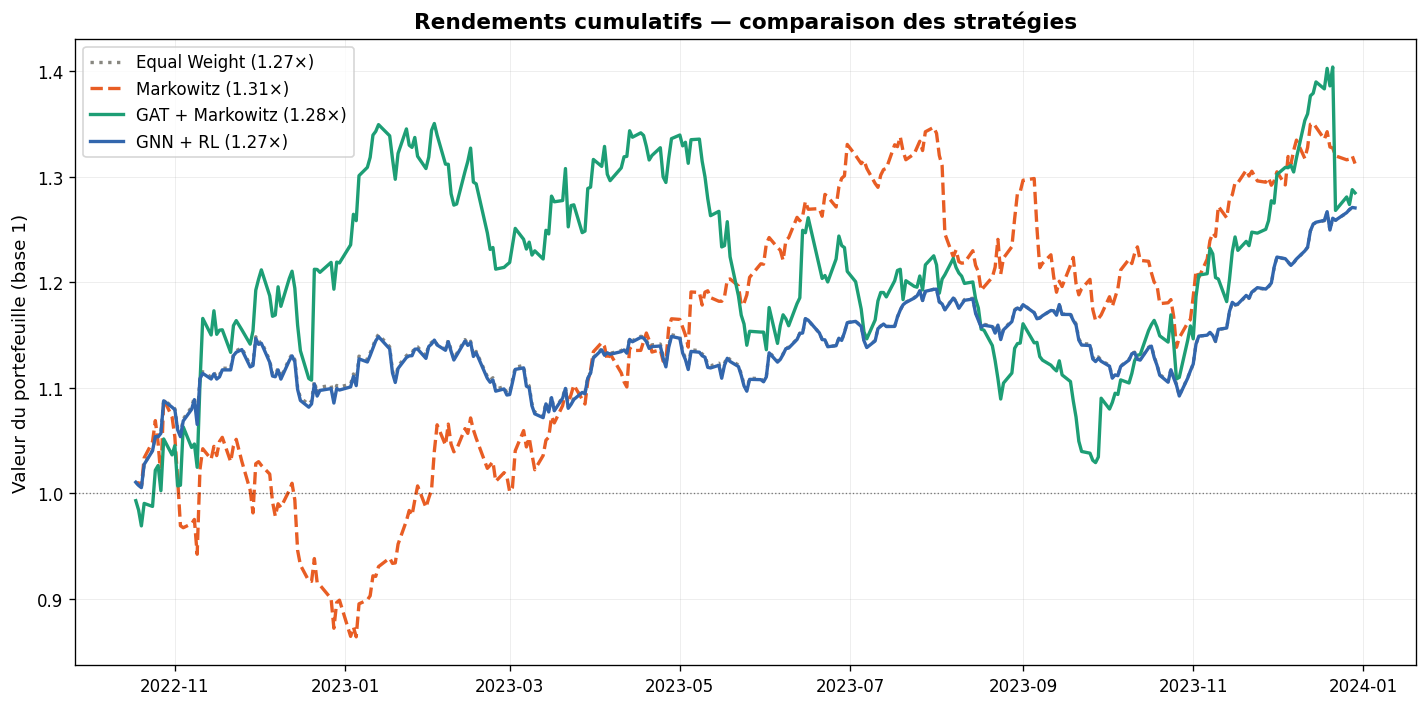

In [11]:
fig = bt.plot_cumulative_returns()
plt.savefig('../data/10_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

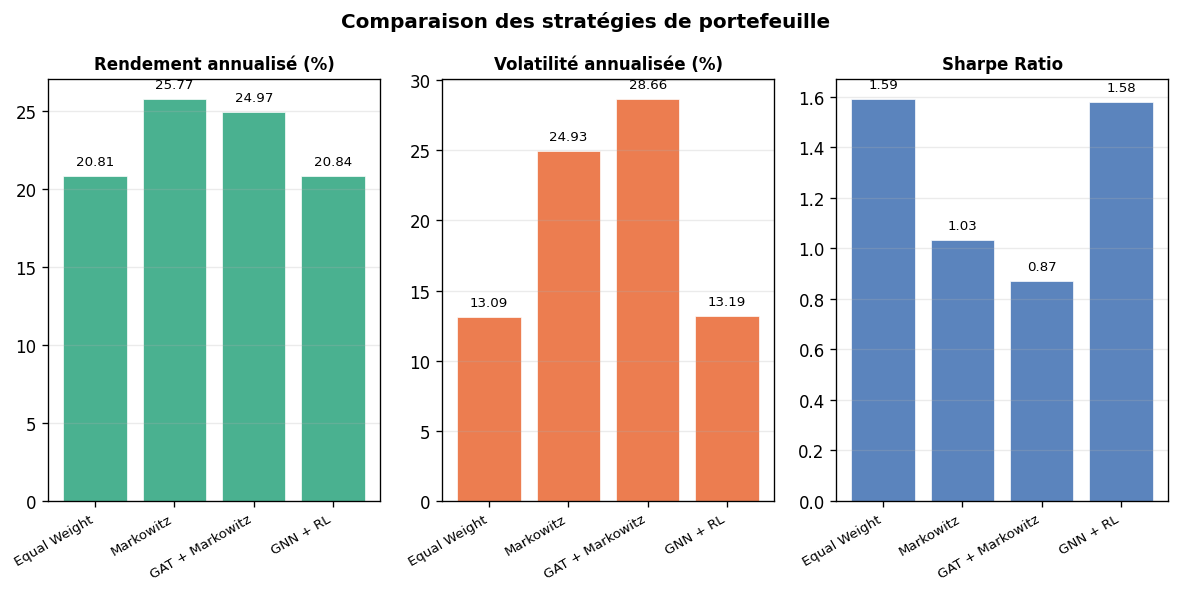

In [12]:
fig = bt.plot_metrics_comparison()
plt.savefig('../data/11_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

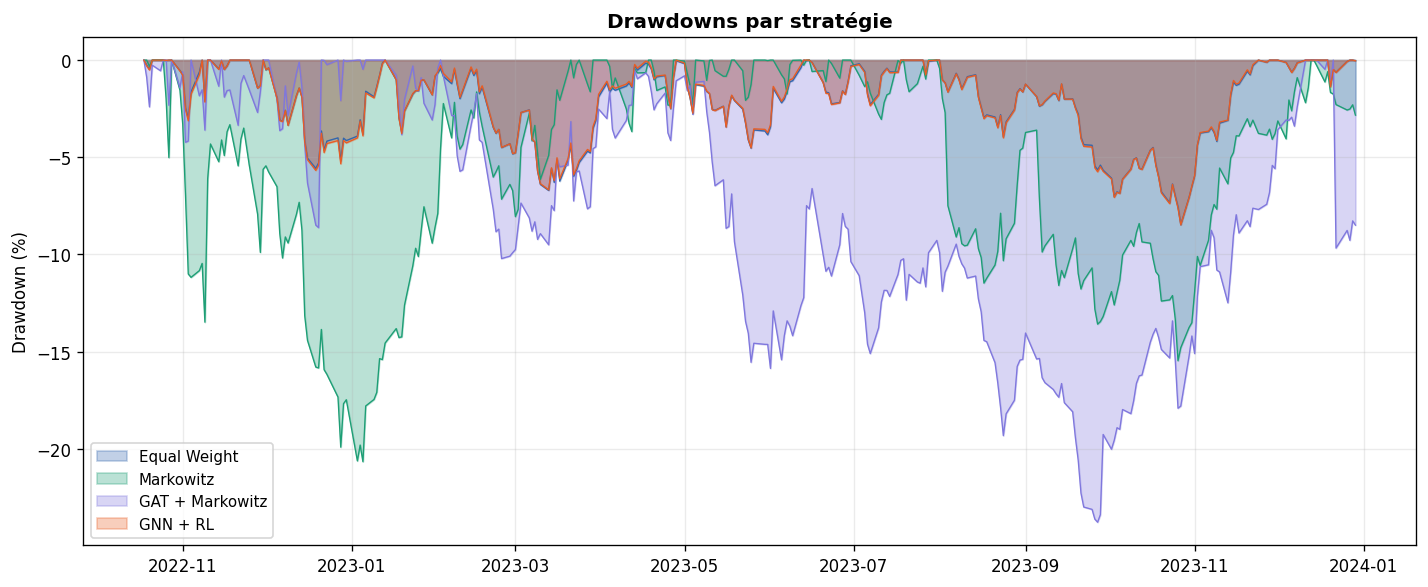

In [13]:
fig = bt.plot_drawdowns()
plt.savefig('../data/12_drawdowns.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interprétation des résultats

**Ce qu'on cherche à montrer** :
- GAT + Markowitz > Markowitz classique → la structure du graphe améliore la prédiction
- GNN + RL ≥ GAT + Markowitz → le RL optimise mieux l'allocation dynamique
- Tous > Equal Weight → les méthodes ML apportent de la valeur

**Limites à mentionner en soutenance** :
- Transaction costs non intégrés dans Markowitz
- Lookahead bias possible si les hyperparamètres ont été choisis sur le test set
- RL encore fragile avec 50 épisodes (instabilité d'entraînement)

In [15]:
# Sauvegarder les résultats finaux
metrics.to_csv('../data/backtest_results.csv')
print("✓ Résultats sauvegardés dans data/backtest_results.csv")
print("\n══ PROJET COMPLET ══")

✓ Résultats sauvegardés dans data/backtest_results.csv

══ PROJET COMPLET ══
